In [1]:
import os
# os.chdir(r"D:\Minor_Project\")
print(os.getcwd())

C:\Users\basan\Desktop\project\Minor_Project


In [2]:
import os
import shutil

# CHANGE THIS PATH to your dataset location
# base_path = r"D:\Minor_Project\maindataset"
base_path = r"maindataset\d1Certificate forgery detection"


# 
# New clean dataset folder
# output_path = r"D:\Minor_Project\dataset_clean"
output_path = r"dataset_clean"


# Create folders
for split in ["train", "val"]:
    for cls in ["real", "fake"]:
        os.makedirs(os.path.join(output_path, split, cls), exist_ok=True)

# Function to process data
def process_folder(split_name, dest_name):
    images_path = os.path.join(base_path, split_name, "images")
    labels_path = os.path.join(base_path, split_name, "labels")

    for file in os.listdir(labels_path):
        if file.endswith(".txt"):
            label_file = os.path.join(labels_path, file)

            with open(label_file, "r") as f:
                first_line = f.readline().strip()

            if not first_line:
                continue

            class_id = int(first_line.split()[0])

            image_name = file.replace(".txt", ".jpg")
            image_path = os.path.join(images_path, image_name)

            if not os.path.exists(image_path):
                continue

            if class_id == 0:
                dest = "fake"
            elif class_id == 1:
                dest = "real"
            else:
                continue

            shutil.copy(image_path, os.path.join(output_path, dest_name, dest, image_name))


# Process train and valid
process_folder("train", "train")
process_folder("valid", "val")

print("✅ DONE! Dataset organized automatically.")

✅ DONE! Dataset organized automatically.


In [3]:
pip install tensorflow

^C
Note: you may need to restart the kernel to use updated packages.


In [4]:
import tensorflow as tf

dataset_path = r"D:\Minor_Project\dataset_clean"

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path + "/train",
    image_size=(224, 224),
    batch_size=32
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path + "/val",
    image_size=(224, 224),
    batch_size=32
)

ModuleNotFoundError: No module named 'tensorflow'

In [11]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
val_data = val_data.map(lambda x, y: (normalization_layer(x), y))

In [13]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
])

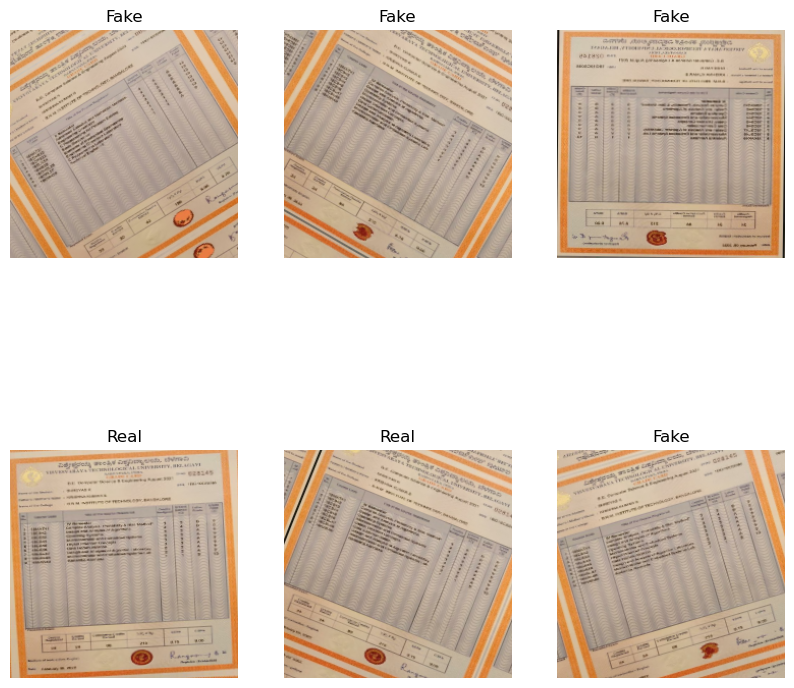

In [14]:
import matplotlib.pyplot as plt

for images, labels in train_data.take(1):
    augmented_images = data_augmentation(images)

    plt.figure(figsize=(10, 10))
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(augmented_images[i].numpy())
        plt.title("Fake" if labels[i]==0 else "Real")
        plt.axis("off")

plt.show()